# Visualisierung von Dariah Topics-Explorer Daten

### Dariah Topics-Explorer liefert bei Export fünf Dateien aus:
1. Stoppwortliste
2. topics (Topics & Wörter)
3. document-similarities (Topics-Verteilung Text zu Text)
4. document-topic-distribution (Topics-Verteilung Topic zu Text)
5. topic-similarities (Ähnlichkeit Topic zu Topic)

### Schritt 1: Topics als Wordcloud Visualisieren

In [225]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# load data
topics = pd.read_csv("topicsexplorer-data/topics.csv", sep=";")

# check df
#print(topics.head())

In [226]:
def plot_topic_wordclouds(
    topics_df,
    topics_to_plot=None,   # e.g. ["Topic 0", "Topic 3"] or [0, 3] or None for all
    top_n_words=30,
    figsize=(10, 5),
    colormap="viridis"
):
    topic_col = topics_df.columns[0]
    word_cols = topics_df.columns[1:]

    if topics_to_plot is None:
        rows = topics_df.iterrows()
    else:
        
        if all(isinstance(t, int) for t in topics_to_plot):
            rows = ((idx, topics_df.iloc[idx]) for idx in topics_to_plot if 0 <= idx < len(topics_df))
        else:
            mask = topics_df[topic_col].astype(str).isin([str(t) for t in topics_to_plot])
            rows = topics_df[mask].iterrows()

    for _, row in rows:
        topic_name = str(row[topic_col]).strip()

        words = [
            str(row[c]).strip()
            for c in word_cols
            if pd.notna(row[c]) and str(row[c]).strip() and str(row[c]).strip().lower() != "nan"
        ]

        if top_n_words <= len(words):
            words = words[:top_n_words]  # keep only the top N words
        else: 
            print(f"Warning: Topic '{topic_name}' has only {len(words)} valid words, less than the requested top {top_n_words}.")       # rank-based weights: earlier words = larger size
        word_freq = {word: len(words) - i for i, word in enumerate(words)}

        wc = WordCloud(
            width=900,
            height=500,
            background_color="white",
            colormap=colormap
        ).generate_from_frequencies(word_freq)

        plt.figure(figsize=figsize)
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(topic_name, fontsize=16)
        plt.show()

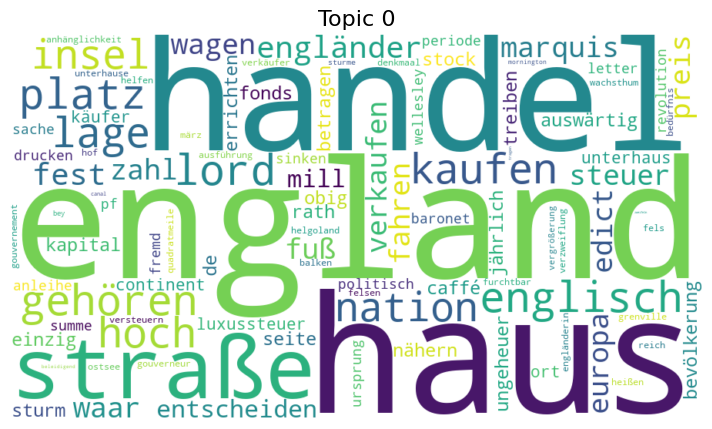

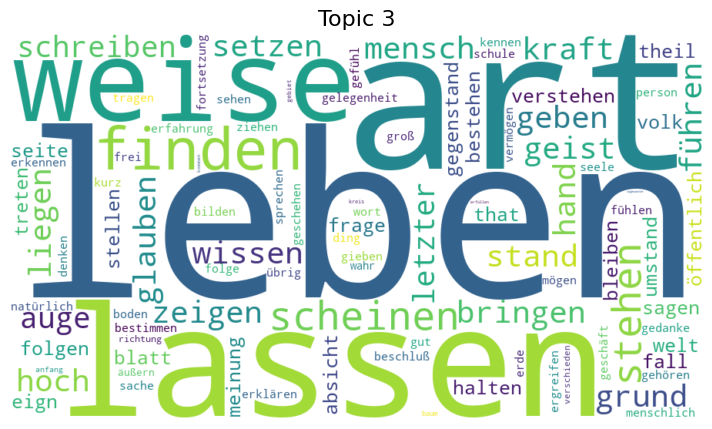

In [227]:
# all topics, top 30 words each
plot_topic_wordclouds(topics, topics_to_plot=["Topic 0", "Topic 3"], top_n_words=100)

### Schritt 2: Ähnlichkeit der Themen

In [265]:
import seaborn as sns
topic_sim = pd.read_csv("topicsexplorer-data/topic-similarities.csv", sep=";")

topic_names = topic_sim.iloc[:, 0].astype(str)
sim_matrix = topic_sim.iloc[:, 1:].copy()
sim_matrix.index = topic_names
sim_matrix.columns = sim_matrix.columns.astype(str)

sim_matrix.head()

,england haus handel,blatt stück berlin,sr hoheit prinzessinn,leben art lassen,leben freund herz,kraus verfasser wissenschaft,thl deutsch universität,fallen körper bringen,jung kind sehen,polizeilich hiesig finden,staat gesetz nation,könig majestät prinz,gott seite bewegung,bild kunst porträt,sprechen pferd anekdote,theater bühne geben,stadt berlin versuch,schiff finden officier,dame stadt empfindung,blatt paris armee
Unnamed: 0,,,,,,,,,,,,,,,,,,,,
bild kunst porträt,0.078894,0.073637,0.059585,0.371374,0.223946,0.128287,0.073725,0.067418,0.151904,0.057209,0.081032,0.108068,0.109778,1.000000,0.068953,0.144025,0.084253,0.081124,0.120721,0.067748
blatt paris armee,0.223025,0.076075,0.223882,0.139041,0.099195,0.051358,0.057053,0.073310,0.128496,0.053931,0.095770,0.272992,0.068535,0.067748,0.091321,0.042696,0.094320,0.219852,0.080557,1.000000
blatt stück berlin,0.123155,1.000000,0.102699,0.125480,0.079422,0.141209,0.171299,0.078298,0.085476,0.076103,0.118468,0.085574,0.093489,0.073637,0.056206,0.090594,0.098300,0.090465,0.073934,0.076075
dame stadt empfindung,0.090901,0.073934,0.092807,0.198901,0.139872,0.045705,0.064511,0.102023,0.150388,0.100074,0.067108,0.070335,0.175253,0.120721,0.161228,0.091777,0.083120,0.081740,1.000000,0.080557
england haus handel,1.000000,0.123155,0.115098,0.228378,0.119095,0.108400,0.077268,0.090380,0.141979,0.160742,0.184266,0.173710,0.107720,0.078894,0.097990,0.081615,0.090644,0.164363,0.090901,0.223025


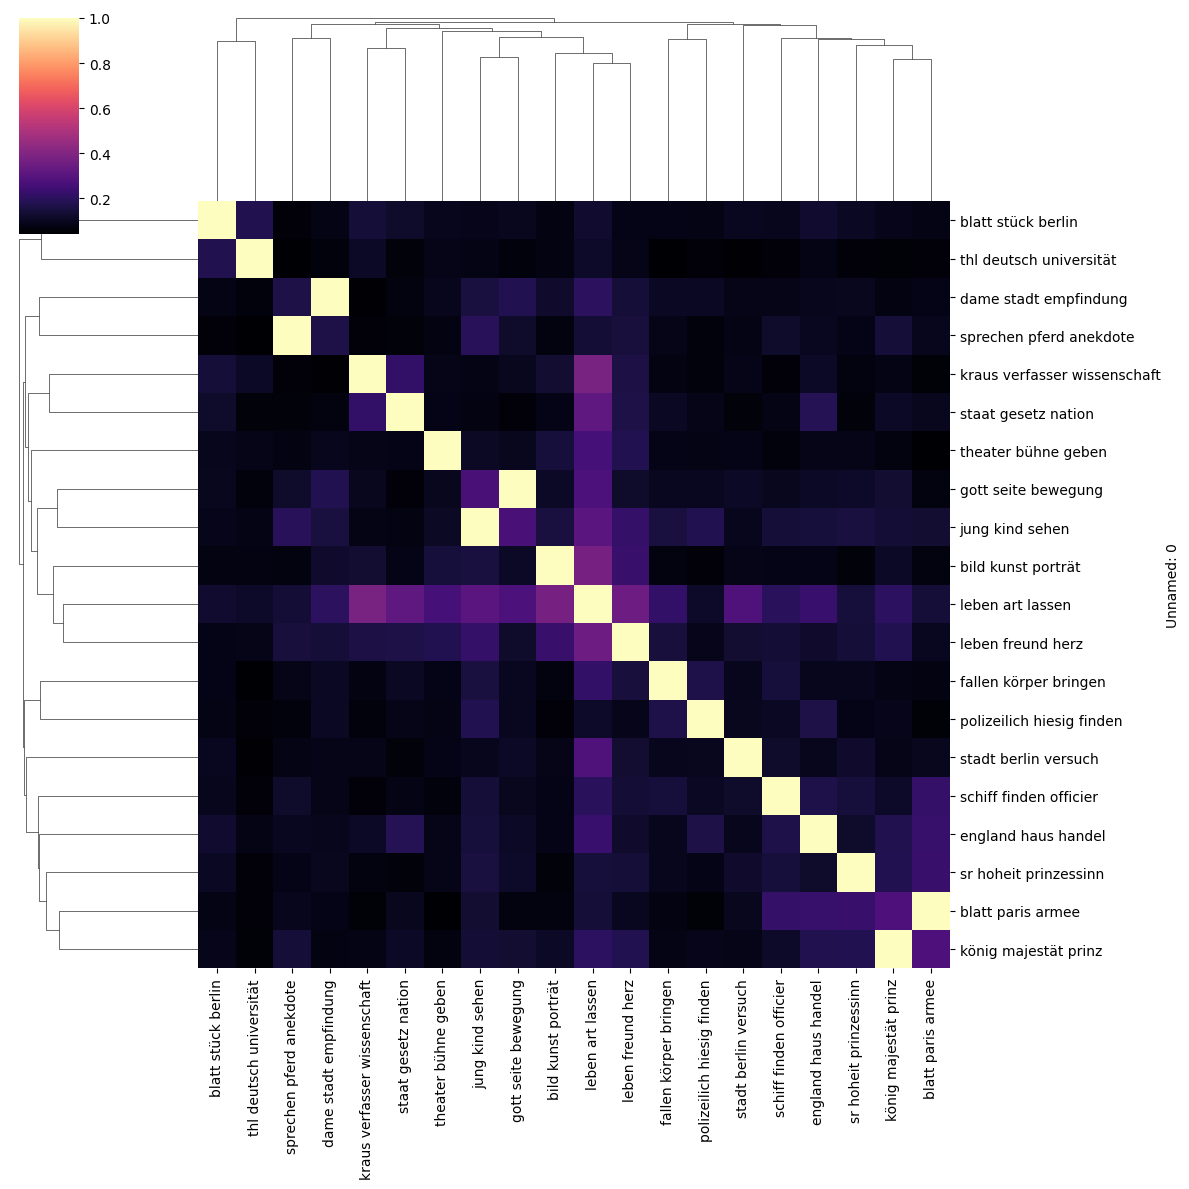

In [266]:
sns.clustermap(
    sim_matrix.astype(float),
    cmap="magma",
    figsize=(12, 12),
    metric="euclidean",
    method="average"
)
plt.show()

In [230]:
def plot_topic_neighbors(topic, top_n=5):
    s = sim_matrix.loc[topic].astype(float).drop(topic).sort_values(ascending=False).head(top_n)

    plt.figure(figsize=(8, 4))
    plt.barh(s.index[::-1], s.values[::-1])
    plt.title(f"Top {top_n} Similar Topics for {topic}")
    plt.xlabel("Similarity")
    plt.tight_layout()
    plt.show()

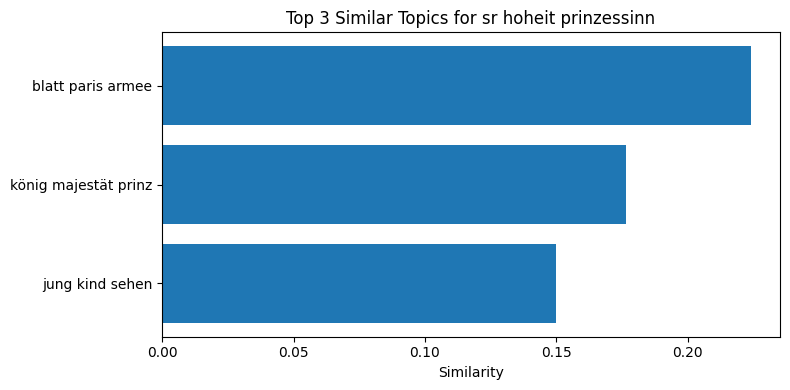

In [231]:
plot_topic_neighbors("sr hoheit prinzessinn", top_n=3)

### Schritt 3: Verteilung der Themen


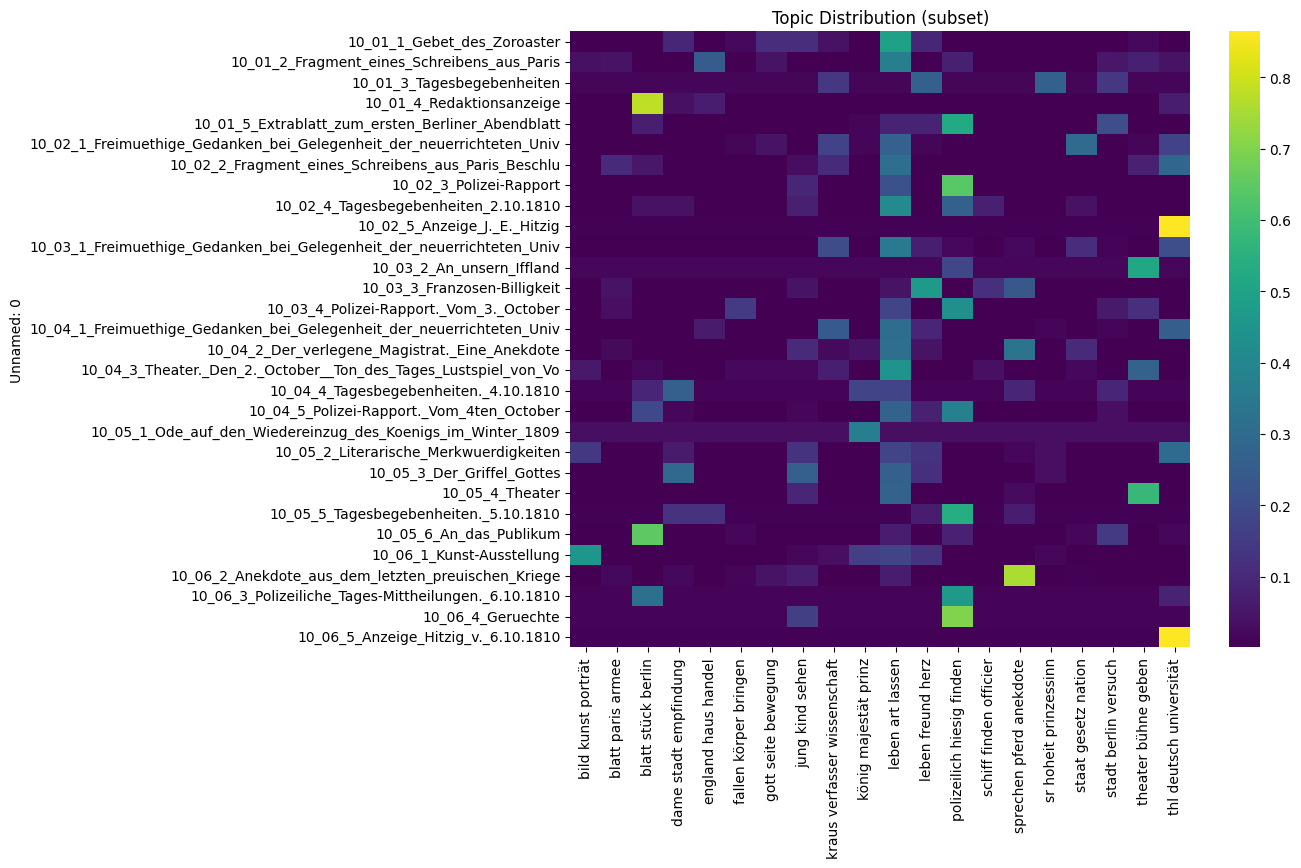

In [232]:
topic_dist = pd.read_csv("topicsexplorer-data/document-topic-distribution.csv", sep=";")
doc_names = topic_dist.iloc[:, 0]
sim_matrix = topic_dist.iloc[:, 1:]
sim_matrix.index = doc_names

# take subset (important!)
subset = sim_matrix.iloc[:30]

plt.figure(figsize=(10, 8))
sns.heatmap(subset.astype(float), cmap="viridis")
plt.title("Topic Distribution (subset)")
plt.show()

### Ähnlichkeit der Texte

In [233]:
doc_sim = pd.read_csv("topicsexplorer-data/document-similarities.csv", sep=";")
doc_ids = doc_sim.iloc[:, 0].astype(str)
sim_matrix = doc_sim.iloc[:, 1:].astype(float)
sim_matrix.index = doc_ids
sim_matrix.columns = sim_matrix.columns.astype(str)

print(sim_matrix.shape)   # should be (407, 407)

(407, 407)


In [260]:
threshold = 0.6  # try 0.4, 0.5, 0.6

G = nx.Graph()

for doc in sim_matrix.index:
    G.add_node(doc)

for i in sim_matrix.index:
    for j in sim_matrix.columns:
        if i < j:  # avoid duplicates
            w = sim_matrix.loc[i, j]
            if w >= threshold:
                G.add_edge(i, j, weight=w)

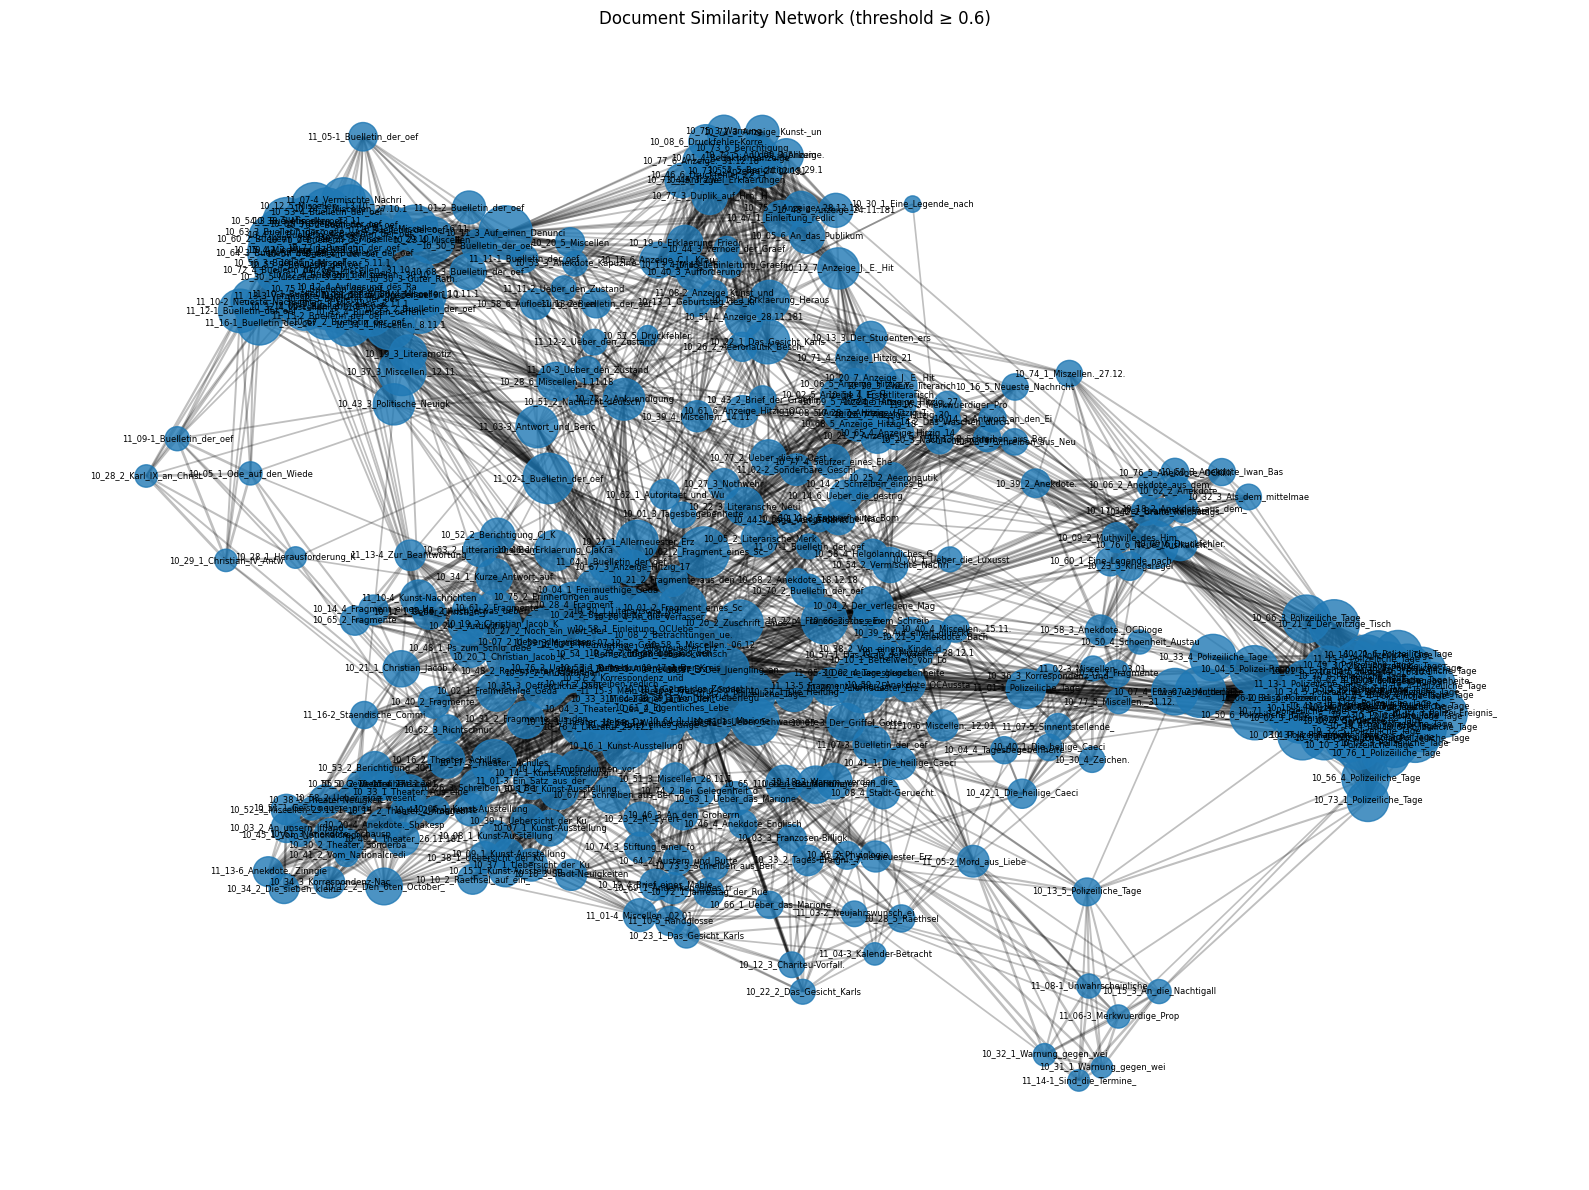

In [261]:
pos = nx.spring_layout(G, seed=42, k=0.6, iterations=200)

plt.figure(figsize=(16, 12))

# node sizes by degree
degrees = dict(G.degree())
node_sizes = [80 + 20 * degrees[n] for n in G.nodes()]

# edge widths by similarity
edge_widths = [G[u][v]["weight"] * 2 for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, alpha=0.8)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.25)
nx.draw_networkx_labels(
    G, pos,
    font_size=6,
    labels={n: n[:25] for n in G.nodes()}  # truncate long document names
)

plt.title(f"Document Similarity Network (threshold ≥ {threshold})")
plt.axis("off")
plt.tight_layout()
plt.show()

### Schritt 5: Verteilung der Themen über die Zeit (Ausgaben)


In [238]:
# first column contains the document IDs / titles
doc_id_col = topic_dist.columns[0]
topic_cols = topic_dist.columns[1:]

topic_map = {
    i + 1: topic_cols[i]   # 1-based numbering
    for i in range(len(topic_cols))
}

topic_labels = {
    num: f"T{num:02d} — {name}"
    for num, name in topic_map.items()
}

print(topic_labels)

# extract year and issue from the document id, e.g. 10_01_1_Gebet_des_Zoroaster
meta = topic_dist[doc_id_col].astype(str).str.extract(
    r'^(?P<yy>\d{2})_(?P<issue>\d{2})[-_]'
)


doc_topics = topic_dist.copy()
doc_topics = doc_topics.join(meta)

# drop rows that did not match the pattern
doc_topics = doc_topics.dropna(subset=["yy", "issue"]).copy()

doc_topics["year"] = 1800 + doc_topics["yy"].astype(int)
doc_topics["issue"] = doc_topics["issue"].astype(int)

issue_topics = (
    doc_topics
    .groupby(["year", "issue"])[list(topic_cols)]
    .mean()
    .sort_index()
)

issue_topics.index = [f"{y}_{i:02d}" for y, i in issue_topics.index]


print(meta.isna().sum())

{1: 'T01 — bild kunst porträt', 2: 'T02 — blatt paris armee', 3: 'T03 — blatt stück berlin', 4: 'T04 — dame stadt empfindung', 5: 'T05 — england haus handel', 6: 'T06 — fallen körper bringen', 7: 'T07 — gott seite bewegung', 8: 'T08 — jung kind sehen', 9: 'T09 — kraus verfasser wissenschaft', 10: 'T10 — könig majestät prinz', 11: 'T11 — leben art lassen', 12: 'T12 — leben freund herz', 13: 'T13 — polizeilich hiesig finden', 14: 'T14 — schiff finden officier', 15: 'T15 — sprechen pferd anekdote', 16: 'T16 — sr hoheit prinzessinn', 17: 'T17 — staat gesetz nation', 18: 'T18 — stadt berlin versuch', 19: 'T19 — theater bühne geben', 20: 'T20 — thl deutsch universität'}
yy       0
issue    0
dtype: int64


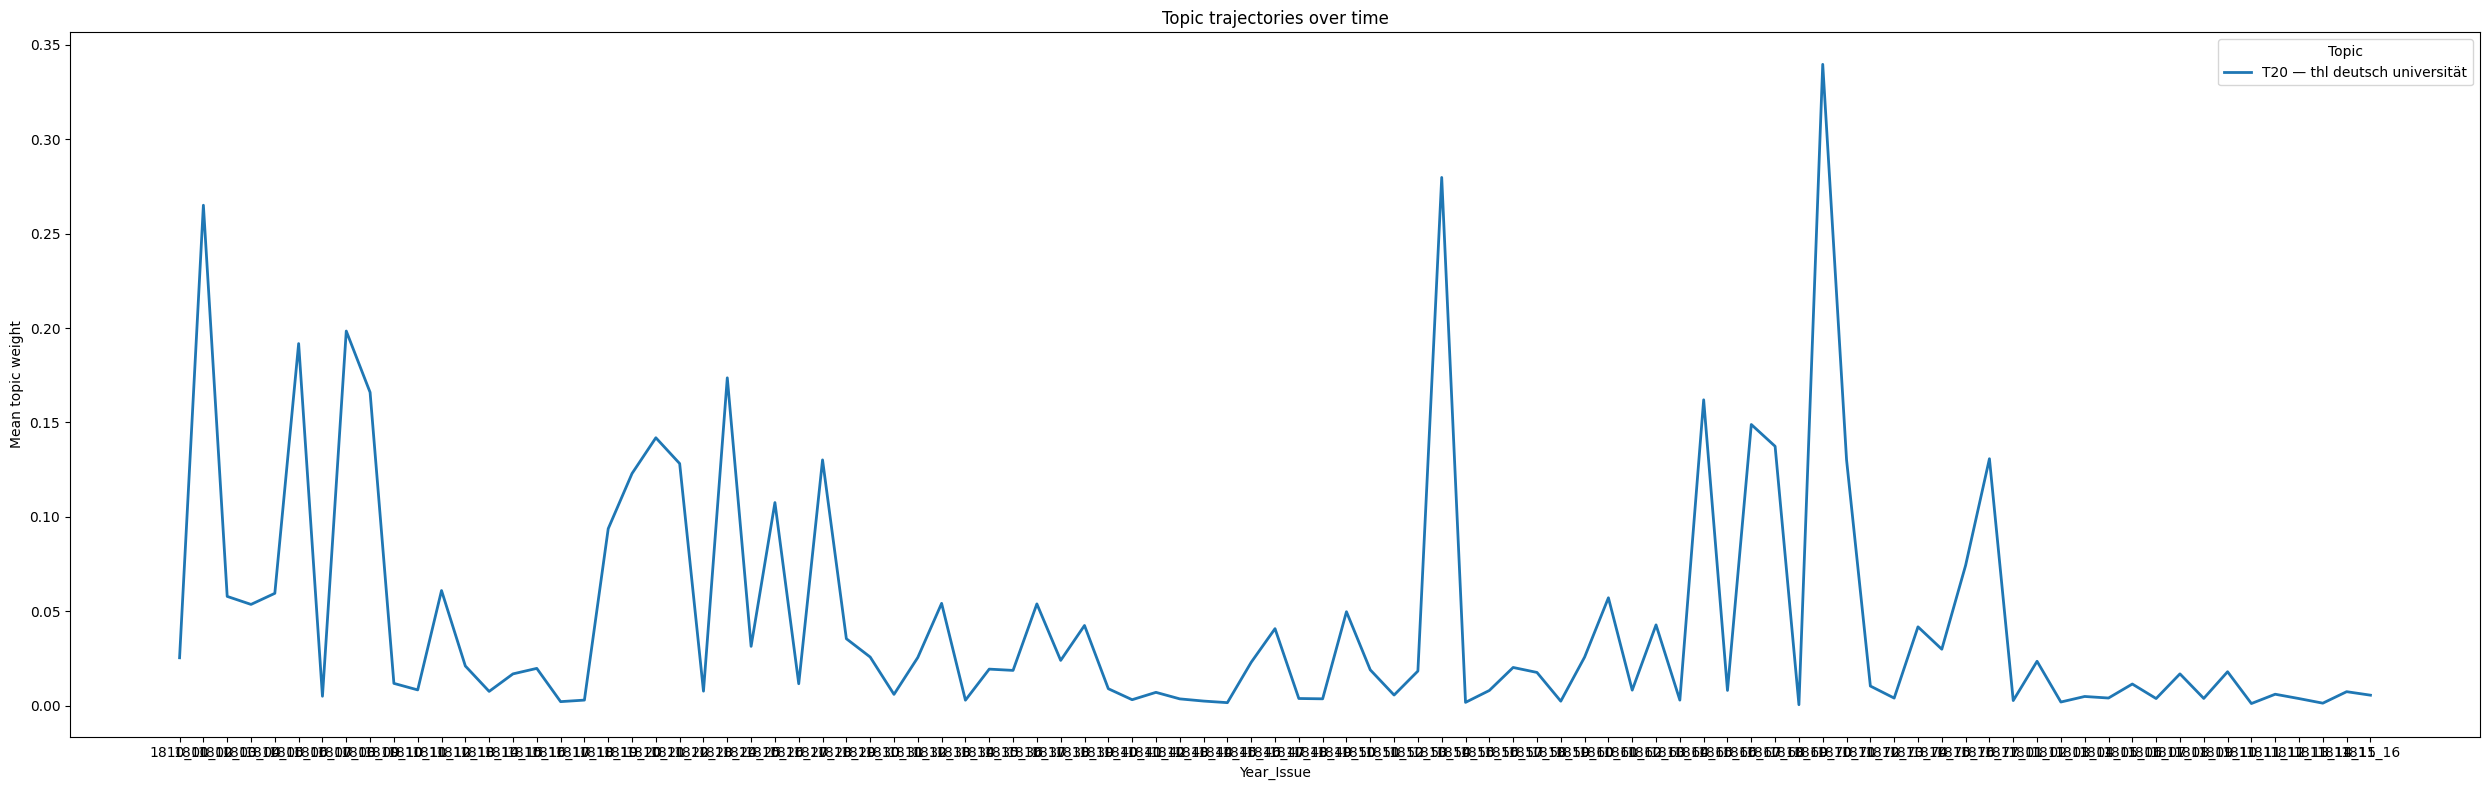

In [259]:
selected_topic_numbers = [20]

selected_topics = [topic_map[n] for n in selected_topic_numbers]

plt.figure(figsize=(25, 8))

for n in selected_topic_numbers:
    col = topic_map[n]
    plt.plot(issue_topics.index, issue_topics[col], linewidth=2, label=topic_labels[n])

plt.ylabel("Mean topic weight")
plt.xlabel("Year_Issue")
plt.title("Topic trajectories over time")
plt.legend(title="Topic")
plt.tight_layout()
plt.show()


Todos:

- [ ] Neu-Berechung der Topic Similarity Matrix unter Ausschluss von outlier-topics?
- [ ] Ausgabe des Netzwerks für Gephi!